# EM算法在高斯混合模型(GMM)上的应用

In [2]:
import numpy as np

### 算法类

In [ ]:
class GaussianMixtureEM:
    """
    使用 EM 算法估计高斯混合模型 GMM 的参数。
    参数：
        n_components : int
            高斯混合成分个数 K。
        max_iter : int
            EM 最大迭代次数。
        tol : float
            收敛阈值。如果两次迭代的对数似然差小于 tol，则停止迭代。
        reg_covar : float
            协方差矩阵正则项，防止协方差矩阵奇异。
        random_state : int or None
            随机种子，保证结果可复现。
    """

    def __init__(
        self,
        n_components=3,
        max_iter=100,
        tol=1e-4,
        reg_covar=1e-6,
        random_state=None
    ):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state
        self.weights_ = None       # alpha_k
        self.means_ = None         # mu_k
        self.covariances_ = None   # Sigma_k
        self.resp_ = None          # gamma_ik
        self.log_likelihoods_ = [] # 每轮迭代的对数似然
        self.n_iter_ = 0
        self.converged_ = False

    def _check_X(self, X):
        """
        检查输入数据格式。
        如果输入是一维数组：
            [1, 2, 3, 4]
        转换成二维形式：
            [[1], [2], [3], [4]]
        """
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if X.ndim != 2:
            raise ValueError("X 必须是二维数组，形状为 (n_samples, n_features)")
        return X

    def _initialize_parameters(self, X):
        """
        初始化 GMM 参数。
        初始化内容：
            1. 混合系数 alpha_k
            2. 均值 mu_k
            3. 协方差矩阵 Sigma_k
        """
        rng = np.random.default_rng(self.random_state) # 创建一个随机数生成器
        n_samples, n_features = X.shape
        self.weights_ = np.ones(self.n_components) / self.n_components # 初始化混合系数，先让每个成分权重相同
        # 随机选择 K 个样本作为初始均值
        indices = rng.choice(
            n_samples,
            size=self.n_components,
            replace=False # 表示不重复选择
        ) # 可能随机选出：[12, 57, 83]
        self.means_ = X[indices].copy() # 把刚才随机选出的样本作为初始均值
        # 使用整体样本协方差作为每个成分的初始协方差
        empirical_cov = np.cov(X.T) # 因为 np.cov() 默认认为每一行是一个变量，每一列是一个观测值。
        if n_features == 1:
            empirical_cov = np.array([[empirical_cov]]) # 如果是一维数据，就把方差这个数字变成1*1矩阵
        empirical_cov += self.reg_covar * np.eye(n_features) # 给协方差矩阵对角线加一个很小的数，防止矩阵不可逆
        self.covariances_ = np.array([ # 把这个协方差矩阵复制K份，作为K个高斯成分的初始协方差矩阵。
            empirical_cov.copy()
            for _ in range(self.n_components)
        ])

    def _log_gaussian_density(self, X, mean, covariance):
        """
        计算多元高斯分布的 log 密度：
            log N(x | mu, Sigma)
        这里不用直接求逆矩阵，而是用Cholesky分解，数值更稳定。
        """
        n_samples, n_features = X.shape
        covariance = covariance + self.reg_covar * np.eye(n_features) # 给协方差矩阵加正则项
        try:
            L = np.linalg.cholesky(covariance) # 给协方差矩阵加正则项
        except np.linalg.LinAlgError:
            covariance = covariance + 10 * self.reg_covar * np.eye(n_features) # 再多加一点正则项，让协方差矩阵更稳定。
            L = np.linalg.cholesky(covariance)

        diff = X - mean
        # 解 L * y = diff.T
        solved = np.linalg.solve(L, diff.T)
        # 马氏距离平方
        mahalanobis = np.sum(solved ** 2, axis=0)
        # log |Sigma| = 2 * sum(log(diag(L)))
        log_det = 2.0 * np.sum(np.log(np.diag(L)))
        log_prob = -0.5 * (
            n_features * np.log(2 * np.pi)
            + log_det
            + mahalanobis
        )
        return log_prob

    def _estimate_log_prob(self, X):
        """
        计算每个样本在每个高斯成分下的 log 概率。
        返回矩阵形状：
            (n_samples, n_components)
        第 i 行第 k 列表示：
            log N(x_i | mu_k, Sigma_k)
        """
        n_samples = X.shape[0]
        log_prob = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            log_prob[:, k] = self._log_gaussian_density(
                X,
                self.means_[k],
                self.covariances_[k]
            )
        return log_prob

    def _logsumexp(self, A, axis=1):
        """
        稳定计算：
            log(sum(exp(A)))
        避免 exp(A) 直接上溢。
        """
        max_A = np.max(A, axis=axis, keepdims=True)
        result = max_A + np.log(
            np.sum(np.exp(A - max_A), axis=axis, keepdims=True)
        )
        return result

    def _e_step(self, X):
        """
        E 步：计算响应度 gamma_ik。
        gamma_ik 表示：
            在当前参数下，样本 x_i 属于第 k 个高斯成分的后验概率。
        """
        log_prob = self._estimate_log_prob(X)
        # log alpha_k + log N(x_i | mu_k, Sigma_k)
        log_weighted_prob = log_prob + np.log(self.weights_)
        # log p(x_i)
        log_prob_norm = self._logsumexp(log_weighted_prob, axis=1)
        # log gamma_ik
        log_resp = log_weighted_prob - log_prob_norm
        # gamma_ik
        resp = np.exp(log_resp)
        # 总对数似然
        log_likelihood = np.sum(log_prob_norm)
        return resp, log_likelihood

    def _m_step(self, X, resp):
        """
        M 步：根据响应度更新模型参数。
        更新：
            1. alpha_k
            2. mu_k
            3. Sigma_k
        """
        n_samples, n_features = X.shape
        # N_k = sum_i gamma_ik
        Nk = np.sum(resp, axis=0) + 10 * np.finfo(float).eps
        # 更新混合系数 alpha_k
        self.weights_ = Nk / n_samples
        # 更新均值 mu_k
        self.means_ = (resp.T @ X) / Nk[:, np.newaxis]
        # 更新协方差矩阵 Sigma_k
        self.covariances_ = np.zeros(
            (self.n_components, n_features, n_features)
        )
        for k in range(self.n_components):
            diff = X - self.means_[k]
            weighted_diff = resp[:, k][:, np.newaxis] * diff
            covariance = (weighted_diff.T @ diff) / Nk[k]
            covariance += self.reg_covar * np.eye(n_features)
            self.covariances_[k] = covariance

    def fit(self, X):
        """
        训练 GMM 模型。
        EM 迭代过程：
            1. 初始化参数
            2. E 步：计算 gamma_ik
            3. M 步：更新 alpha_k, mu_k, Sigma_k
            4. 计算对数似然
            5. 判断是否收敛
        """
        X = self._check_X(X)

        self._initialize_parameters(X)

        prev_log_likelihood = None

        for iteration in range(1, self.max_iter + 1):
            # E 步
            resp, log_likelihood = self._e_step(X)

            # M 步
            self._m_step(X, resp)

            self.resp_ = resp
            self.log_likelihoods_.append(log_likelihood)
            self.n_iter_ = iteration

            # 判断收敛
            if prev_log_likelihood is not None:
                change = abs(log_likelihood - prev_log_likelihood)

                if change < self.tol:
                    self.converged_ = True
                    break

            prev_log_likelihood = log_likelihood

        return self

    def predict_proba(self, X):
        """
        返回每个样本属于每个高斯成分的概率。

        也就是响应度矩阵 gamma。
        """
        X = self._check_X(X)
        resp, _ = self._e_step(X)
        return resp

    def predict(self, X):
        """
        返回每个样本最可能属于的高斯成分编号。
        """
        resp = self.predict_proba(X)
        return np.argmax(resp, axis=1)

    def score_samples(self, X):
        """
        返回每个样本的 log p(x_i)。
        """
        X = self._check_X(X)

        log_prob = self._estimate_log_prob(X)
        log_weighted_prob = log_prob + np.log(self.weights_)
        log_prob_norm = self._logsumexp(log_weighted_prob, axis=1)

        return log_prob_norm.ravel()

    def score(self, X):
        """
        返回平均对数似然。
        """
        return np.mean(self.score_samples(X))

    def fit_predict(self, X):
        """
        训练模型，并返回聚类结果。
        """
        self.fit(X)
        return self.predict(X)

### 测试

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 生成模拟数据
np.random.seed(0)

X1 = np.random.normal(loc=-3, scale=0.8, size=100)
X2 = np.random.normal(loc=2, scale=1.0, size=120)
X3 = np.random.normal(loc=6, scale=0.7, size=80)

X = np.concatenate([X1, X2, X3]).reshape(-1, 1)

# 训练 GMM-EM 模型
model = GaussianMixtureEM(
    n_components=3,
    max_iter=200,
    tol=1e-5,
    random_state=42
)

labels = model.fit_predict(X)

print("是否收敛:", model.converged_)
print("迭代次数:", model.n_iter_)
print("混合系数 alpha:")
print(model.weights_)

print("均值 mu:")
print(model.means_)

print("协方差 Sigma:")
print(model.covariances_)

是否收敛: True
迭代次数: 48
混合系数 alpha:
[0.40478932 0.33281458 0.2623961 ]
均值 mu:
[[ 2.11231439]
 [-2.95415042]
 [ 5.9450906 ]]
协方差 Sigma:
[[[1.0896776]]

 [[0.6492514]]

 [[0.455374 ]]]


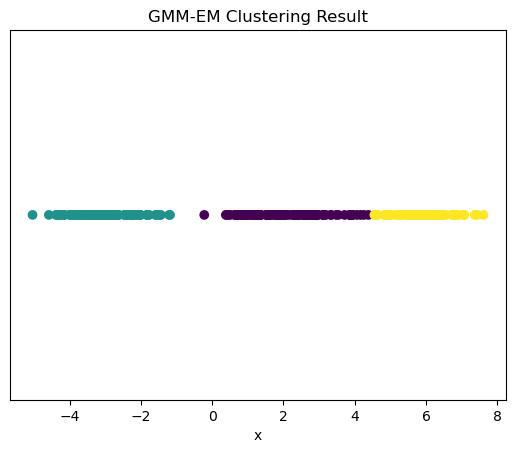

In [5]:
plt.scatter(X[:, 0], np.zeros_like(X[:, 0]), c=labels)
plt.title("GMM-EM Clustering Result")
plt.xlabel("x")
plt.yticks([])
plt.show()